# Home Credit Default Risk Project

## Load Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
from google.colab import files
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
import shap

In [ ]:
# If you want to check your kagglehub just uncomment the comment under this
#print(kagglehub.__version__)

## Download Datasets from kaggle

In [ ]:
files.upload()

# Create Folder if not exist
!mkdir -p ~/.kaggle

# Move file
!cp kaggle.json ~/.kaggle/

# Set the permission so it will be save
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Authentication success!")

Saving kaggle.json to kaggle.json
✅ Authentication success!


In [ ]:
# Download
!kaggle competitions download -c home-credit-default-risk

# Extractto datasets folder
!mkdir -p datasets
!unzip -q home-credit-default-risk.zip -d datasets

# Check is the file already exist
print("List of file that already been success to download: ")
print(os.listdir('datasets'))

100% 688M/688M [00:06<00:00, 104MB/s]

List of file that already been success to download: 
['HomeCredit_columns_description.csv', 'previous_application.csv', 'application_test.csv', 'POS_CASH_balance.csv', 'installments_payments.csv', 'application_train.csv', 'sample_submission.csv', 'bureau.csv', 'credit_card_balance.csv', 'bureau_balance.csv']


## Load Datasets

In [ ]:
# Function to reduce the size of datasets so it can optimized the ram function
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory reduced to {end_mem:.2f} MB')
    return df

# Read the main table
df_train = pd.read_csv('/content/datasets/application_train.csv')
df_train = reduce_mem_usage(df_train)

print(f"\nData Size: {df_train.shape[0]} row, {df_train.shape[1]} column")

Memory reduced to 128.16 MB

Data Size: 307511 row, 122 column


In [ ]:
df_train.sample(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
78890,191448,0,Cash loans,M,N,N,1,202500.0,143910.0,15628.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,5.0
253360,393175,0,Cash loans,M,Y,Y,0,135000.0,315000.0,11443.5,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,4.0
170509,297616,0,Cash loans,F,N,N,2,67500.0,284400.0,16456.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
138405,260495,0,Cash loans,F,Y,N,1,225000.0,1303200.0,46809.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
151566,275685,0,Cash loans,F,N,Y,0,315000.0,1800000.0,59620.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


## Explaratory Data Analysis (EDA)

### Check for the null values

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float32(65), int16(2), int32(2), int8(37), object(16)
memory usage: 128.2+ MB


In [ ]:
df_train.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [ ]:
def health_data_audit(df):
    # Calculating Null and Percentage
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df)) * 100

    # Preparing the Summary DataFrame
    audit_df = pd.DataFrame({
        'Tipe Data': df.dtypes,
        'Jumlah Null': null_counts,
        'Persentase Null (%)': null_pct.round(2),
        'Jumlah Unik': df.nunique()
    })

    # Anomaly Detection (Numerical & Categorical)
    anomali_notes = []

    for col in df.columns:
        note = "-"
        # Cek Anomali Numerik
        if df[col].dtype != 'object':
            # Deteksi nilai 365243 yang legendaris di dataset ini
            if (df[col] == 365243).any():
                note = "ADA ANOMALI 365243 (1000 thn)"
            # Deteksi Outlier Ekstrem (Sederhana: > 5x Standar Deviasi)
            elif df[col].std() > 0:
                mean = df[col].mean()
                std = df[col].std()
                outliers = df[(df[col] > mean + 5*std) | (df[col] < mean - 5*std)]
                if len(outliers) > 0:
                    note = f"Ada {len(outliers)} Outlier Ekstrem"

        # Cek Anomali Kategorikal (XNA atau Unknown)
        else:
            xna_count = (df[col] == 'XNA').sum()
            unknown_count = (df[col] == 'Unknown').sum()
            if xna_count > 0 or unknown_count > 0:
                note = f"Ada {xna_count} 'XNA' / {unknown_count} 'Unknown'"

        anomali_notes.append(note)

    audit_df['Catatan Anomali'] = anomali_notes

    # Urutkan berdasarkan persentase null tertinggi
    return audit_df.sort_values(by='Persentase Null (%)', ascending=False)

# Cara Pakai:
laporan_kesehatan = health_data_audit(df_train)
laporan_kesehatan.head(20) # Lihat 20 teratas dengan null terbanyak

,Tipe Data,Jumlah Null,Persentase Null (%),Jumlah Unik,Catatan Anomali
COMMONAREA_AVG,float32,214865,69.87,3181,Ada 665 Outlier Ekstrem
COMMONAREA_MODE,float32,214865,69.87,3128,Ada 661 Outlier Ekstrem
COMMONAREA_MEDI,float32,214865,69.87,3202,Ada 668 Outlier Ekstrem
NONLIVINGAPARTMENTS_MEDI,float32,213514,69.43,214,Ada 481 Outlier Ekstrem
NONLIVINGAPARTMENTS_MODE,float32,213514,69.43,167,Ada 444 Outlier Ekstrem
NONLIVINGAPARTMENTS_AVG,float32,213514,69.43,386,Ada 468 Outlier Ekstrem
FONDKAPREMONT_MODE,object,210295,68.39,4,-
LIVINGAPARTMENTS_AVG,float32,210199,68.35,1868,Ada 408 Outlier Ekstrem
LIVINGAPARTMENTS_MEDI,float32,210199,68.35,1097,Ada 410 Outlier Ekstrem
LIVINGAPARTMENTS_MODE,float32,210199,68.35,736,Ada 423 Outlier Ekstrem


### Check for the dupliactes data

In [ ]:
df_train.duplicated().any()

np.False_

### Check the imbalance of data

Good Customer (0): 282686 (91.93%)
Failed to pay customer (1): 24825 (8.07%)


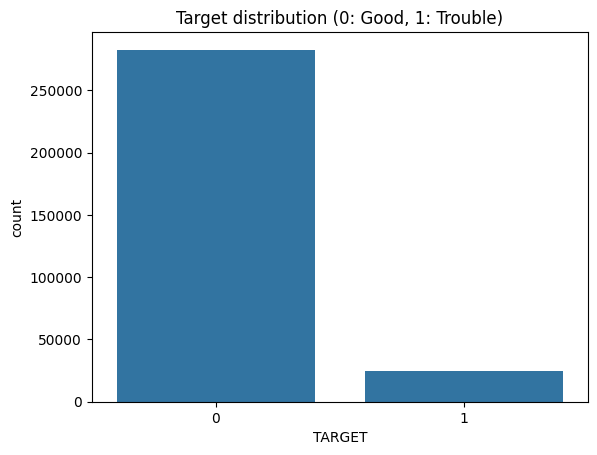

In [ ]:
target_counts = df_train['TARGET'].value_counts()
target_percentage = df_train['TARGET'].value_counts(normalize=True) * 100

print(f"Good Customer (0): {target_counts[0]} ({target_percentage[0]:.2f}%)")
print(f"Failed to pay customer (1): {target_counts[1]} ({target_percentage[1]:.2f}%)")

sns.countplot(x='TARGET', data=df_train)
plt.title('Target distribution (0: Good, 1: Trouble)')
plt.show()

### Descriptive statistic

In [ ]:
df_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990259e+05,27108.572266,5.383961e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371759e+05,4.024795e+05,14493.233398,3.695427e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083758,0.110626,0.204412,0.916884,0.795006,1.869927
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [ ]:
df_train['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,307511.000000
mean,-16036.995067
std,4363.988632
min,-25229.000000
25%,-19682.000000
50%,-15750.000000
75%,-12413.000000
max,-7489.000000


In [ ]:
# Make a new column name age according to data from DAYS_BIRTH
df_train['AGE'] = df_train['DAYS_BIRTH'] / -365
print(df_train['AGE'].describe())

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE, dtype: float64


### Check the corelation

In [ ]:
# Check the corelation so we can prioritize only the column that have high corelation with the target
correlations = df_train.corr(numeric_only=True)['TARGET'].sort_values()

print('Korelasi Positif Tertinggi:\n', correlations.tail(10))
print('\nKorelasi Negatif Tertinggi:\n', correlations.head(10))

Korelasi Positif Tertinggi:
 FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Korelasi Negatif Tertinggi:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
AGE                          -0.078239
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
Name: TARGET, dtype: float64


### Univariate Analysis

In [ ]:
def plot_automated_analysis(df, features):
    # Pastikan TARGET adalah integer agar palette {0:..., 1:...} bekerja
    # Jika sudah integer, baris ini tidak akan merubah apa pun.
    temp_df_plot = df.copy()
    temp_df_plot['TARGET'] = temp_df_plot['TARGET'].astype(int)

    for col in features:
        # Cek apakah kolom ada di dataframe (menghindari error jika ada typo)
        if col not in temp_df_plot.columns:
            print(f"⚠️ Kolom {col} tidak ditemukan.")
            continue

        plt.figure(figsize=(15, 5))

        # --- JIKA KOLOM NUMERIK ---
        if temp_df_plot[col].dtype != 'object' and temp_df_plot[col].nunique() > 20:
            # Subplot 1: KDE Plot
            plt.subplot(1, 2, 1)
            sns.kdeplot(temp_df_plot[temp_df_plot['TARGET'] == 0][col], label='Lancar (0)', fill=True, color='green')
            sns.kdeplot(temp_df_plot[temp_df_plot['TARGET'] == 1][col], label='Macet (1)', fill=True, color='red')
            plt.title(f'Distribusi KDE {col} by Target')
            plt.legend()

            # Subplot 2: Boxplot
            plt.subplot(1, 2, 2)
            # Kita gunakan list warna saja agar lebih aman dari error tipe data dictionary
            sns.boxplot(x='TARGET', y=col, data=temp_df_plot, palette=['green', 'red'])
            plt.title(f'Boxplot {col} by Target')

        # --- JIKA KOLOM KATEGORIKAL ---
        else:
            # Hitung default rate
            counts = temp_df_plot.groupby(col)['TARGET'].value_counts(normalize=True).unstack().fillna(0)
            if 1 in counts.columns:
                counts = counts.sort_values(by=1, ascending=False)

            # Subplot 1: Countplot
            plt.subplot(1, 2, 1)
            sns.countplot(y=col, data=temp_df_plot, order=counts.index, palette='viridis')
            plt.title(f'Jumlah Nasabah per {col}')

            # Subplot 2: Default Rate (%)
            plt.subplot(1, 2, 2)
            if 1 in counts.columns:
                counts[1].plot(kind='barh', color='darkred')
                plt.title(f'Persentase Gagal Bayar (%) per {col}')
                plt.xlabel('Default Rate (Ratio)')
            else:
                plt.text(0.5, 0.5, 'Tidak ada data Gagal Bayar', ha='center')

        plt.tight_layout()
        plt.show()

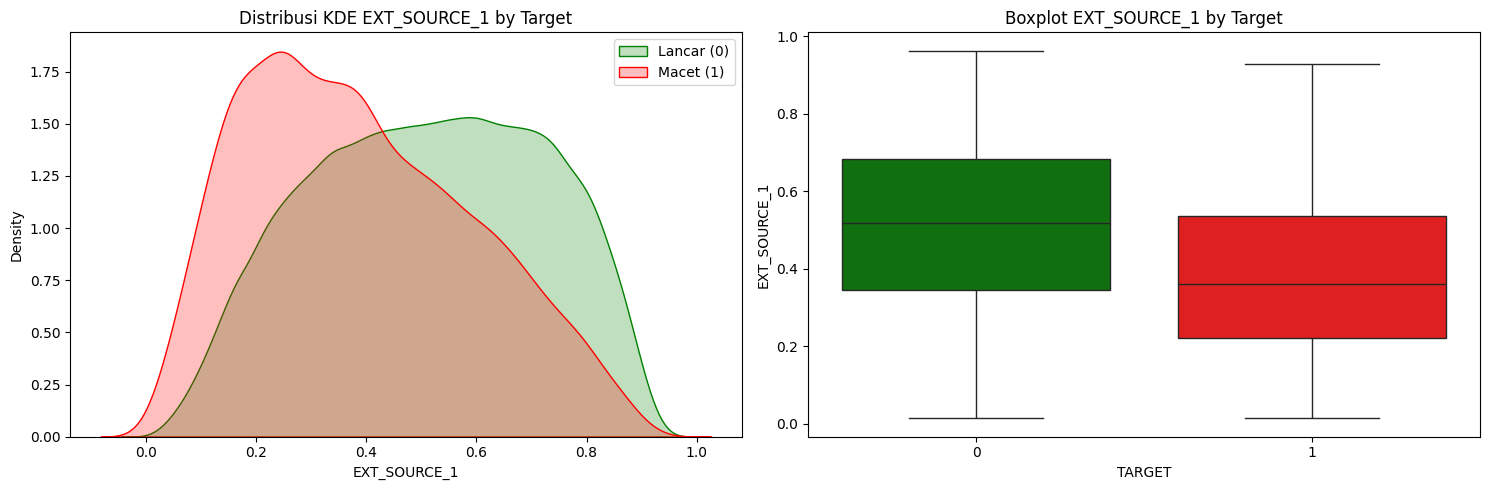

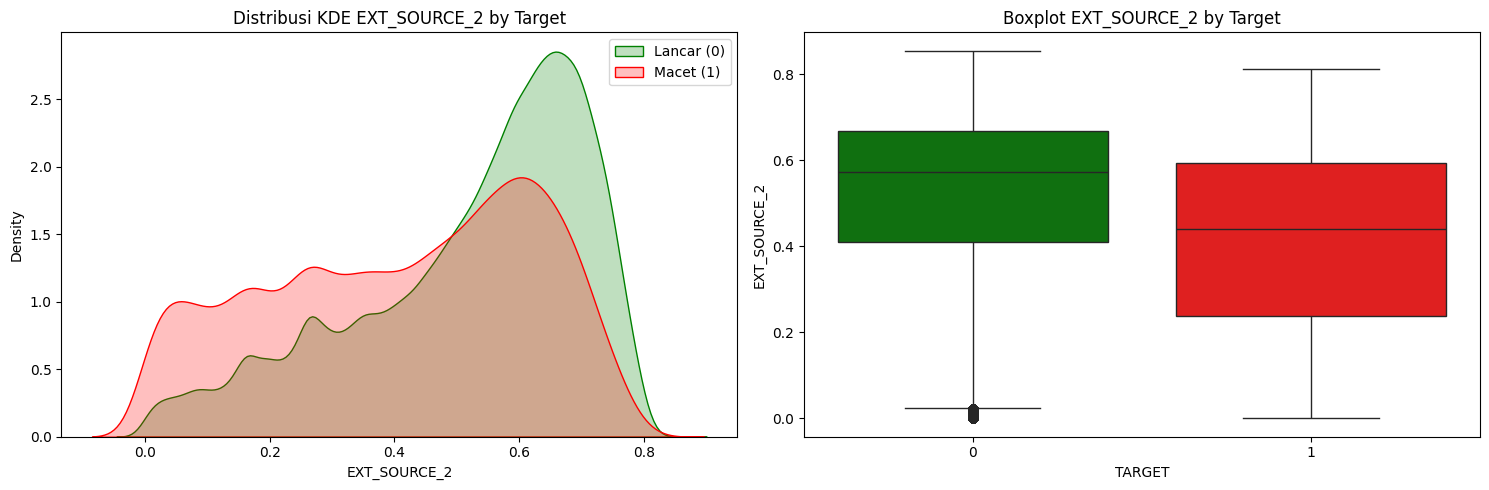

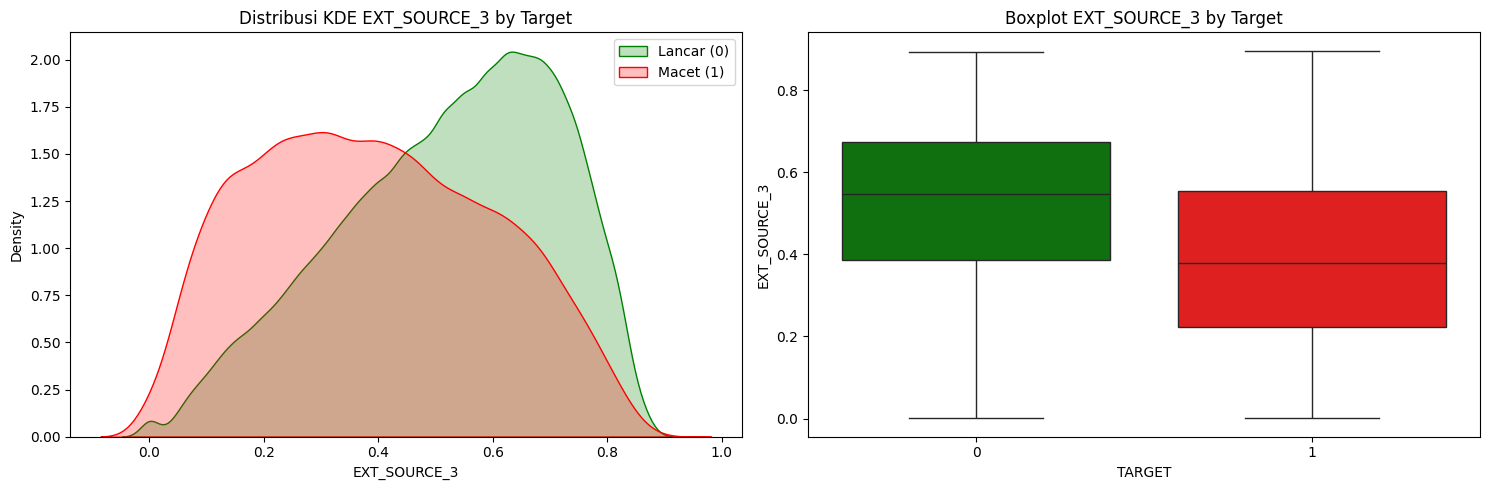

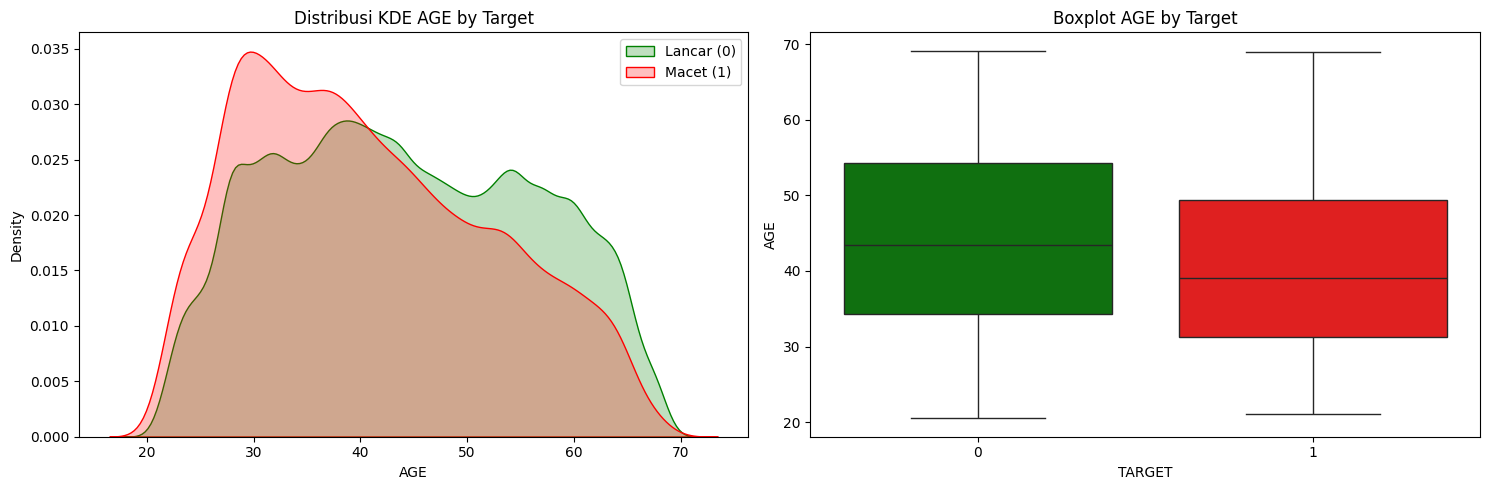

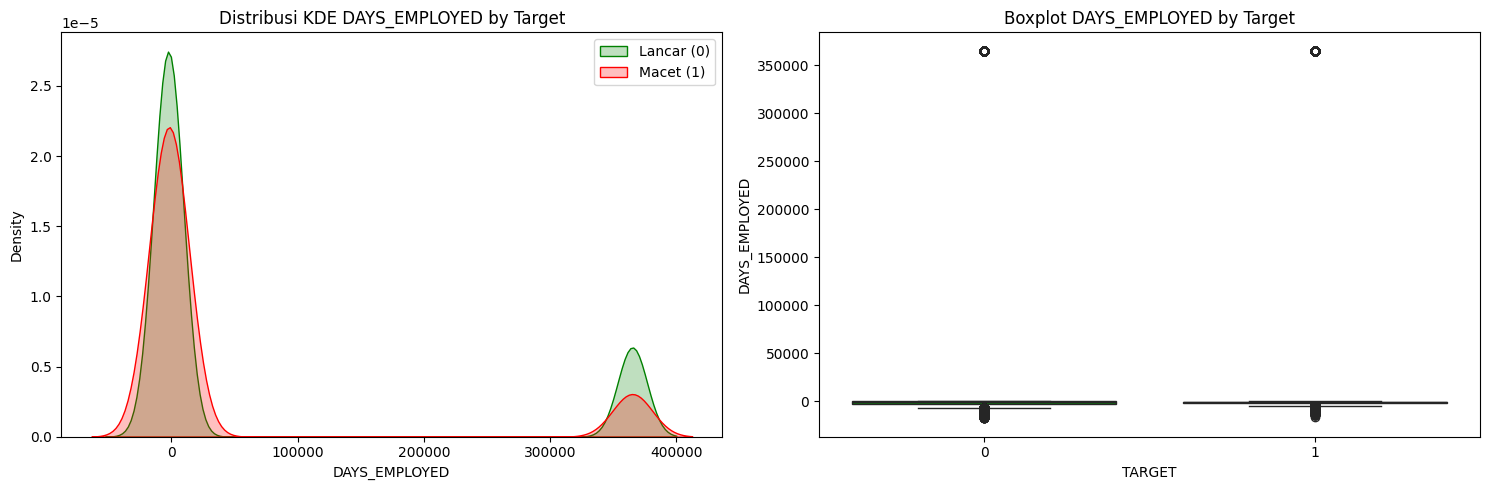

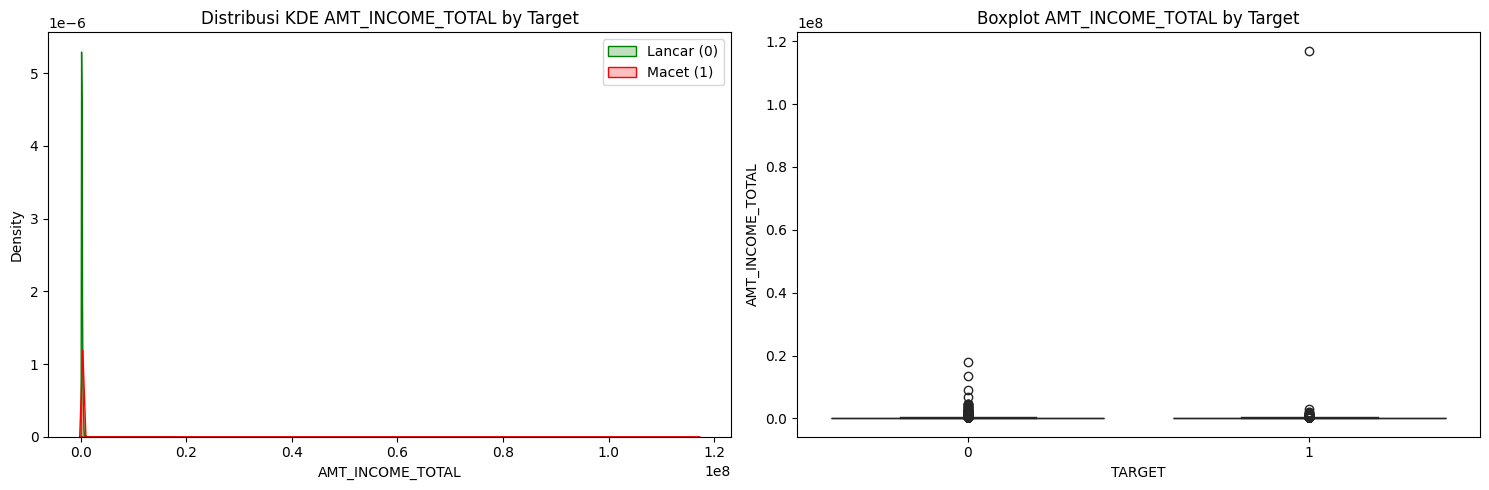

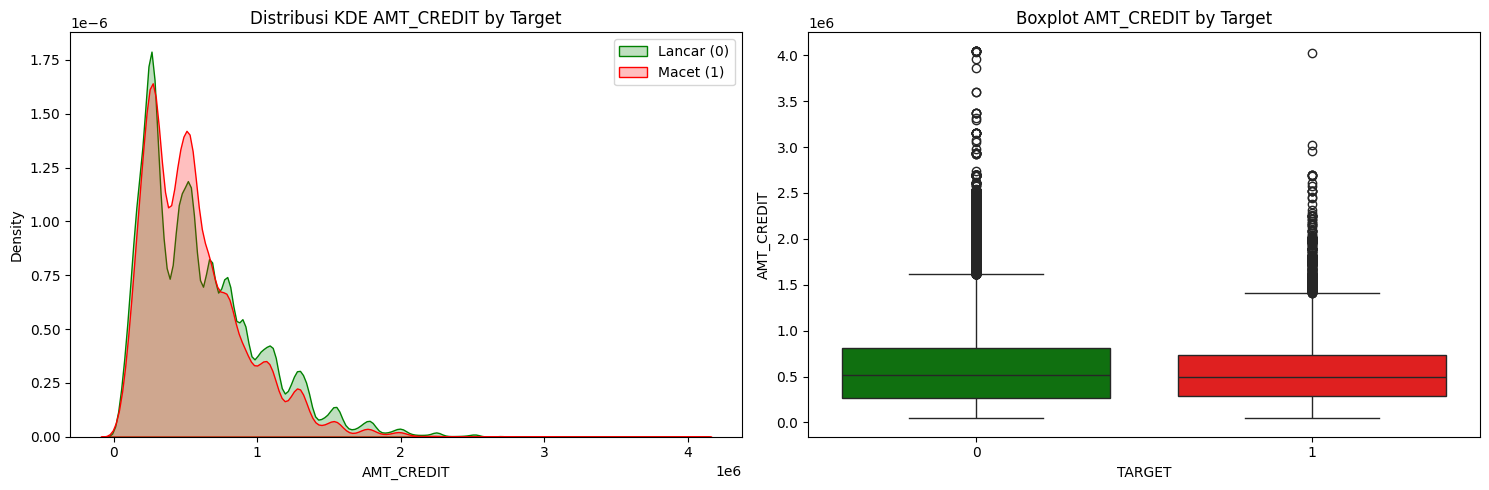

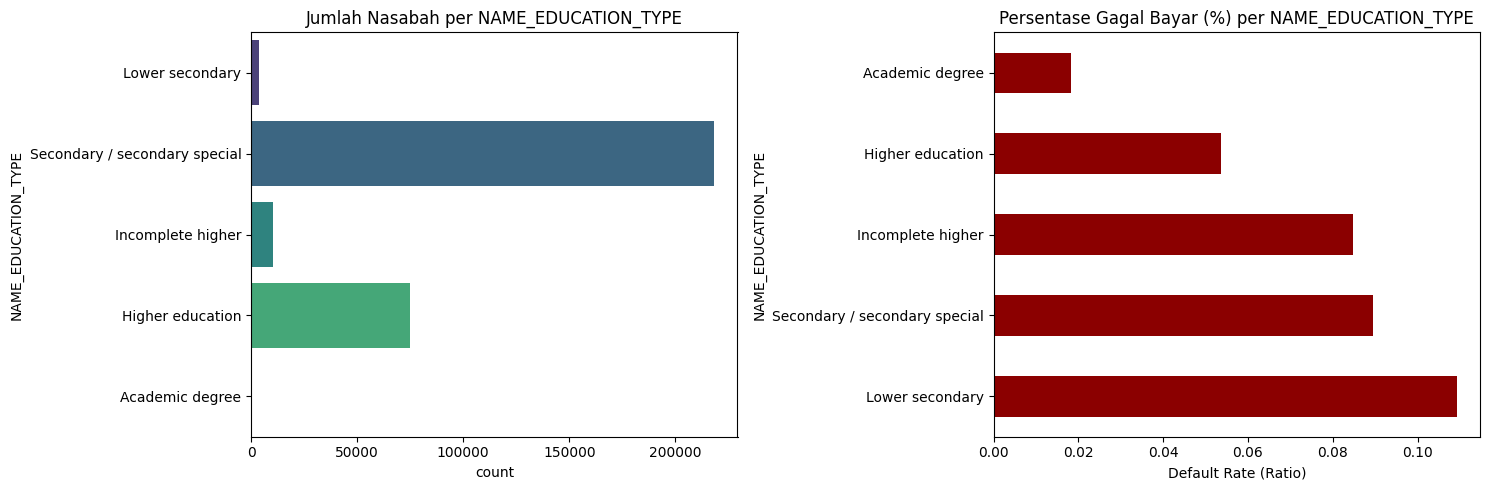

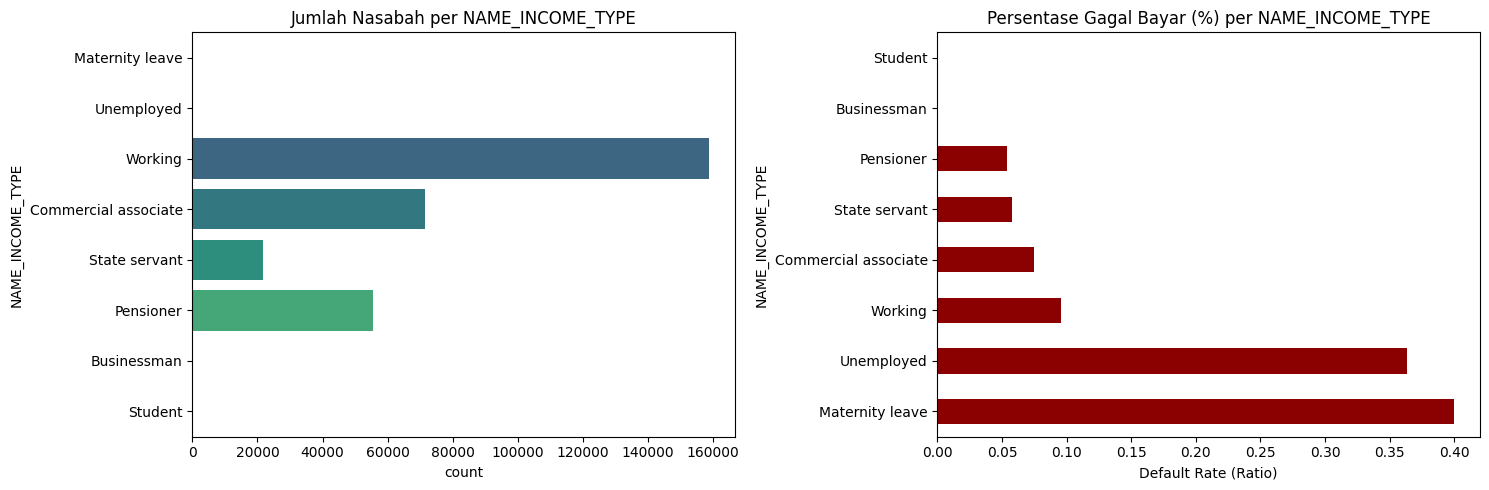

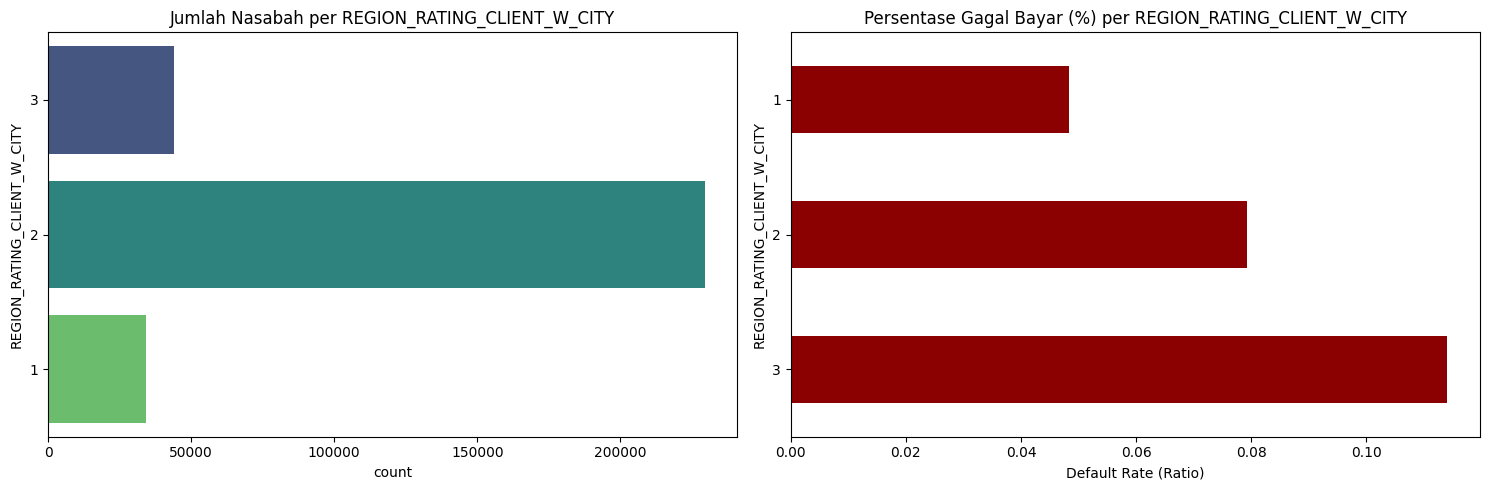

In [ ]:
# Daftar 10 Kolom Wajib Pantau (Berdasarkan Diskusi & Korelasi kamu)
top_10_features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', # The Big Three
    'AGE', 'DAYS_EMPLOYED',                         # Stabilitas Usia & Kerja
    'AMT_INCOME_TOTAL', 'AMT_CREDIT',               # Kapasitas Finansial
    'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE',      # Profil Sosio-Ekonomi
    'REGION_RATING_CLIENT_W_CITY'                  # Rating Lokasi (Korelasi Positif Tinggi)
]

# Jalankan fungsinya
plot_automated_analysis(df_train, top_10_features)

### Multivariate Analysis

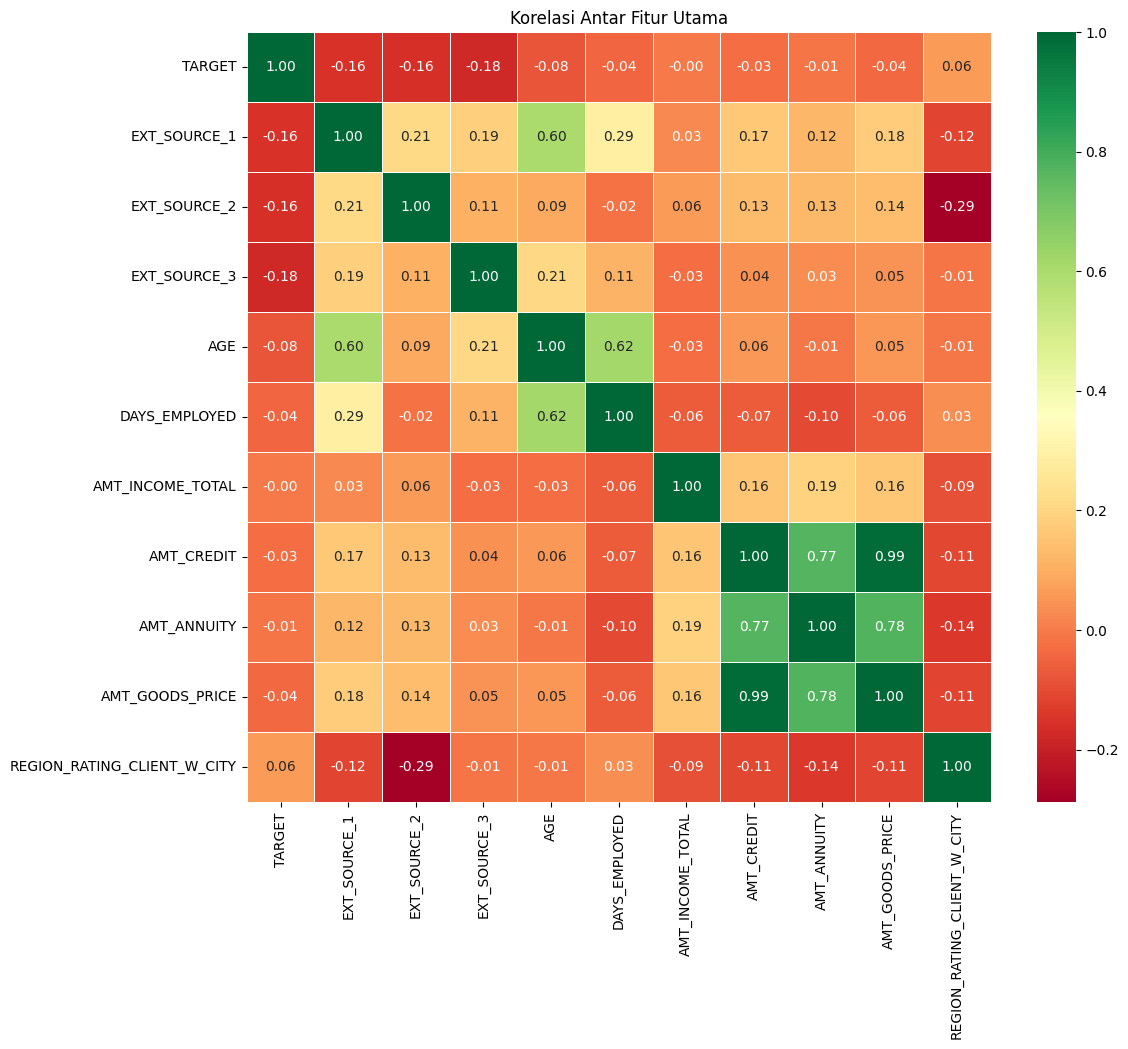

In [ ]:
# Menghitung matriks korelasi untuk fitur pilihan
relevant_features = [
    'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AGE', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
    'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_RATING_CLIENT_W_CITY'
]

# Pastikan hanya menggunakan data numerik
corr_matrix = df_train[relevant_features].corr()

# Visualisasi dengan Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Fitur Utama')
plt.show()

## Feature Engineering

In [ ]:
def perform_feature_engineering(df):
    # 1. Menangani Anomali DAYS_EMPLOYED (seperti temuan kita kemarin)
    # Kita buat kolom flag dulu sebelum nilainya diubah
    df['DAYS_EMPLOYED_ANOM'] = df["DAYS_EMPLOYED"] == 365243
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

    # 2. Fitur Rasio Finansial (Capacity)
    # Berapa besar cicilan dibandingkan pendapatan?
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

    # Berapa besar pinjaman dibandingkan pendapatan?
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

    # Berapa besar harga barang dibandingkan pinjaman? (Mendeteksi DP)
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

    # 3. Fitur Stabilitas (Character)
    # Berapa persen masa hidup yang digunakan untuk bekerja?
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

    # 4. Fitur Interaksi External Sources (The Big Three)
    # Kita buat statistik sederhana dari ketiga skor eksternal
    ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    df['EXT_SOURCES_MEAN'] = df[ext_sources].mean(axis=1)
    df['EXT_SOURCES_NAN_COUNT'] = df[ext_sources].isnull().sum(axis=1)

    print(f"✅ Feature Engineering Selesai. Total Kolom Sekarang: {df.shape[1]}")
    return df

In [ ]:
# Eksekusi
df_train = perform_feature_engineering(df_train)

✅ Feature Engineering Selesai. Total Kolom Sekarang: 131


In [ ]:
training_medians = ['DAYS_EMPLOYED', 'AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'AMT_GOODS_PRICE',
                    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

df_train[training_medians].median()

,0
DAYS_EMPLOYED,-1648.000000
AMT_ANNUITY,24903.000000
AMT_CREDIT,513531.000000
AMT_INCOME_TOTAL,147150.000000
DAYS_BIRTH,-15750.000000
AMT_GOODS_PRICE,450000.000000
EXT_SOURCE_1,0.505998
EXT_SOURCE_2,0.565961
EXT_SOURCE_3,0.535276


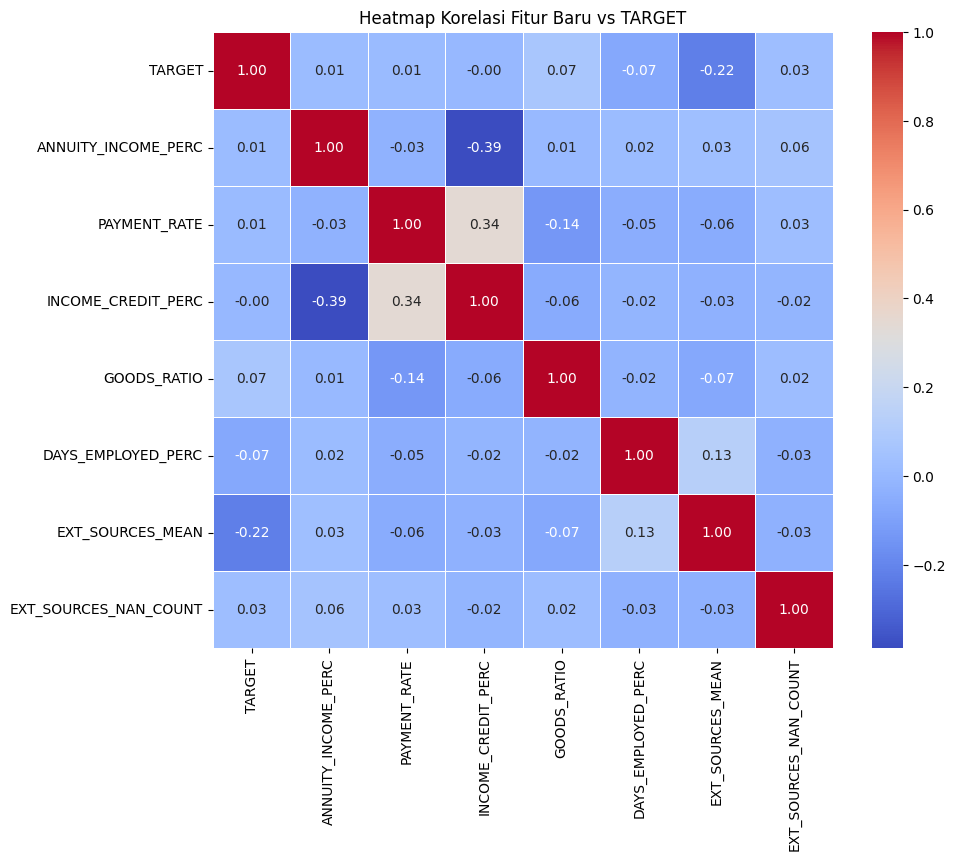

In [ ]:
# 1. Daftar fitur baru + TARGET
new_features_list = [
    'TARGET', 'ANNUITY_INCOME_PERC', 'PAYMENT_RATE',
    'INCOME_CREDIT_PERC', 'GOODS_RATIO',
    'DAYS_EMPLOYED_PERC', 'EXT_SOURCES_MEAN', 'EXT_SOURCES_NAN_COUNT'
]

# 2. Menghitung matriks korelasi
corr_new = df_train[new_features_list].corr()

# 3. Visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_new, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Baru vs TARGET')
plt.show()

## Data Preprocessing

In [ ]:
def automated_preprocessing(df, target_col='TARGET'):
    # 1. Daftar Kolom yang Digunakan dalam Modelling
    # Termasuk fitur asli dan fitur hasil engineering kemarin
    features_to_keep = [
        # Target
        'TARGET',
        # External Sources
        'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
        'EXT_SOURCES_MEAN', 'EXT_SOURCES_NAN_COUNT',
        # Demografi & Stabilitas
        'AGE', 'DAYS_EMPLOYED', 'DAYS_EMPLOYED_PERC', 'DAYS_EMPLOYED_ANOM',
        # Finansial Ratios
        'ANNUITY_INCOME_PERC', 'PAYMENT_RATE', 'INCOME_CREDIT_PERC', 'GOODS_RATIO',
        'AMT_ANNUITY', 'AMT_CREDIT',
        # Kategorikal
        'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'REGION_RATING_CLIENT_W_CITY'
    ]

    # 2. Slice Dataframe hanya untuk kolom terpilih
    df_model = df[features_to_keep].copy()

    # 3. Handling Boolean (DAYS_EMPLOYED_ANOM)
    # Mengubah True/False menjadi 1/0
    if 'DAYS_EMPLOYED_ANOM' in df_model.columns:
        df_model['DAYS_EMPLOYED_ANOM'] = df_model['DAYS_EMPLOYED_ANOM'].astype(int)

    # 4. Grouping Kategorikal Lemah (Optional but Recommended)
    # Menggabungkan kategori langka seperti 'Maternity leave' agar tidak overfitting
    if 'NAME_INCOME_TYPE' in df_model.columns:
        valid_incomes = ['Working', 'Commercial associate', 'Pensioner', 'State servant']
        df_model['NAME_INCOME_TYPE'] = df_model['NAME_INCOME_TYPE'].apply(lambda x: x if x in valid_incomes else 'Other')

    # 5. One-Hot Encoding untuk Fitur Kategorikal
    # Ini akan mengubah teks menjadi kolom-kolom angka (0 dan 1)
    categorical_cols = ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']
    df_model = pd.get_dummies(df_model, columns=categorical_cols, dummy_na=False, dtype=int)

    # 6. Imputing Missing Values (Numerical)
    # Mengisi sisa NaN dengan Median karena lebih robust terhadap outlier
    numeric_cols = df_model.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col != target_col: # Jangan impute Target
            median_val = df_model[col].median()
            df_model[col].fillna(median_val, inplace=True)

    print(f"✅ Preprocessing Selesai!")
    print(f"Bentuk Data Akhir: {df_model.shape}")
    print(f"Jumlah Nilai Null Tersisa: {df_model.isnull().sum().sum()}")

    return df_model

In [ ]:
# Eksekusi
df_ready = automated_preprocessing(df_train)

✅ Preprocessing Selesai!
Bentuk Data Akhir: (307511, 27)
Jumlah Nilai Null Tersisa: 0


In [ ]:
df_ready.sample(5)

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCES_MEAN,EXT_SOURCES_NAN_COUNT,AGE,DAYS_EMPLOYED,DAYS_EMPLOYED_PERC,DAYS_EMPLOYED_ANOM,...,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Other,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Working
199988,0,0.505671,0.323274,0.370650,0.399865,0,39.167123,-1699.0,0.118844,0,...,0,0,0,0,1,0,0,0,0,1
60613,0,0.430899,0.671975,0.367291,0.490055,0,37.589041,-224.0,0.016327,0,...,0,0,0,0,1,0,0,0,1,0
85979,0,0.098551,0.791465,0.835777,0.575264,0,50.005479,-262.0,0.014355,0,...,0,1,0,0,0,0,0,0,0,1
112443,0,0.505998,0.670832,0.535276,0.670832,2,52.295890,-1061.0,0.055585,0,...,0,0,0,0,1,0,0,0,0,1
296322,0,0.576383,0.388668,0.535276,0.482526,1,27.630137,-1923.0,0.190679,0,...,0,1,0,0,0,0,0,0,0,1


--- Nilai Skewness (Urut dari Tertinggi) ---
INCOME_CREDIT_PERC     223.811432
DAYS_EMPLOYED_PERC       1.619578
AMT_ANNUITY              1.579824
GOODS_RATIO              1.556876
ANNUITY_INCOME_PERC      1.512052
AMT_CREDIT               1.234778
PAYMENT_RATE             1.116902
AGE                      0.115673
EXT_SOURCE_1            -0.150998
EXT_SOURCES_MEAN        -0.529829
EXT_SOURCE_3            -0.537697
EXT_SOURCE_2            -0.795940
DAYS_EMPLOYED           -2.295849
dtype: float64


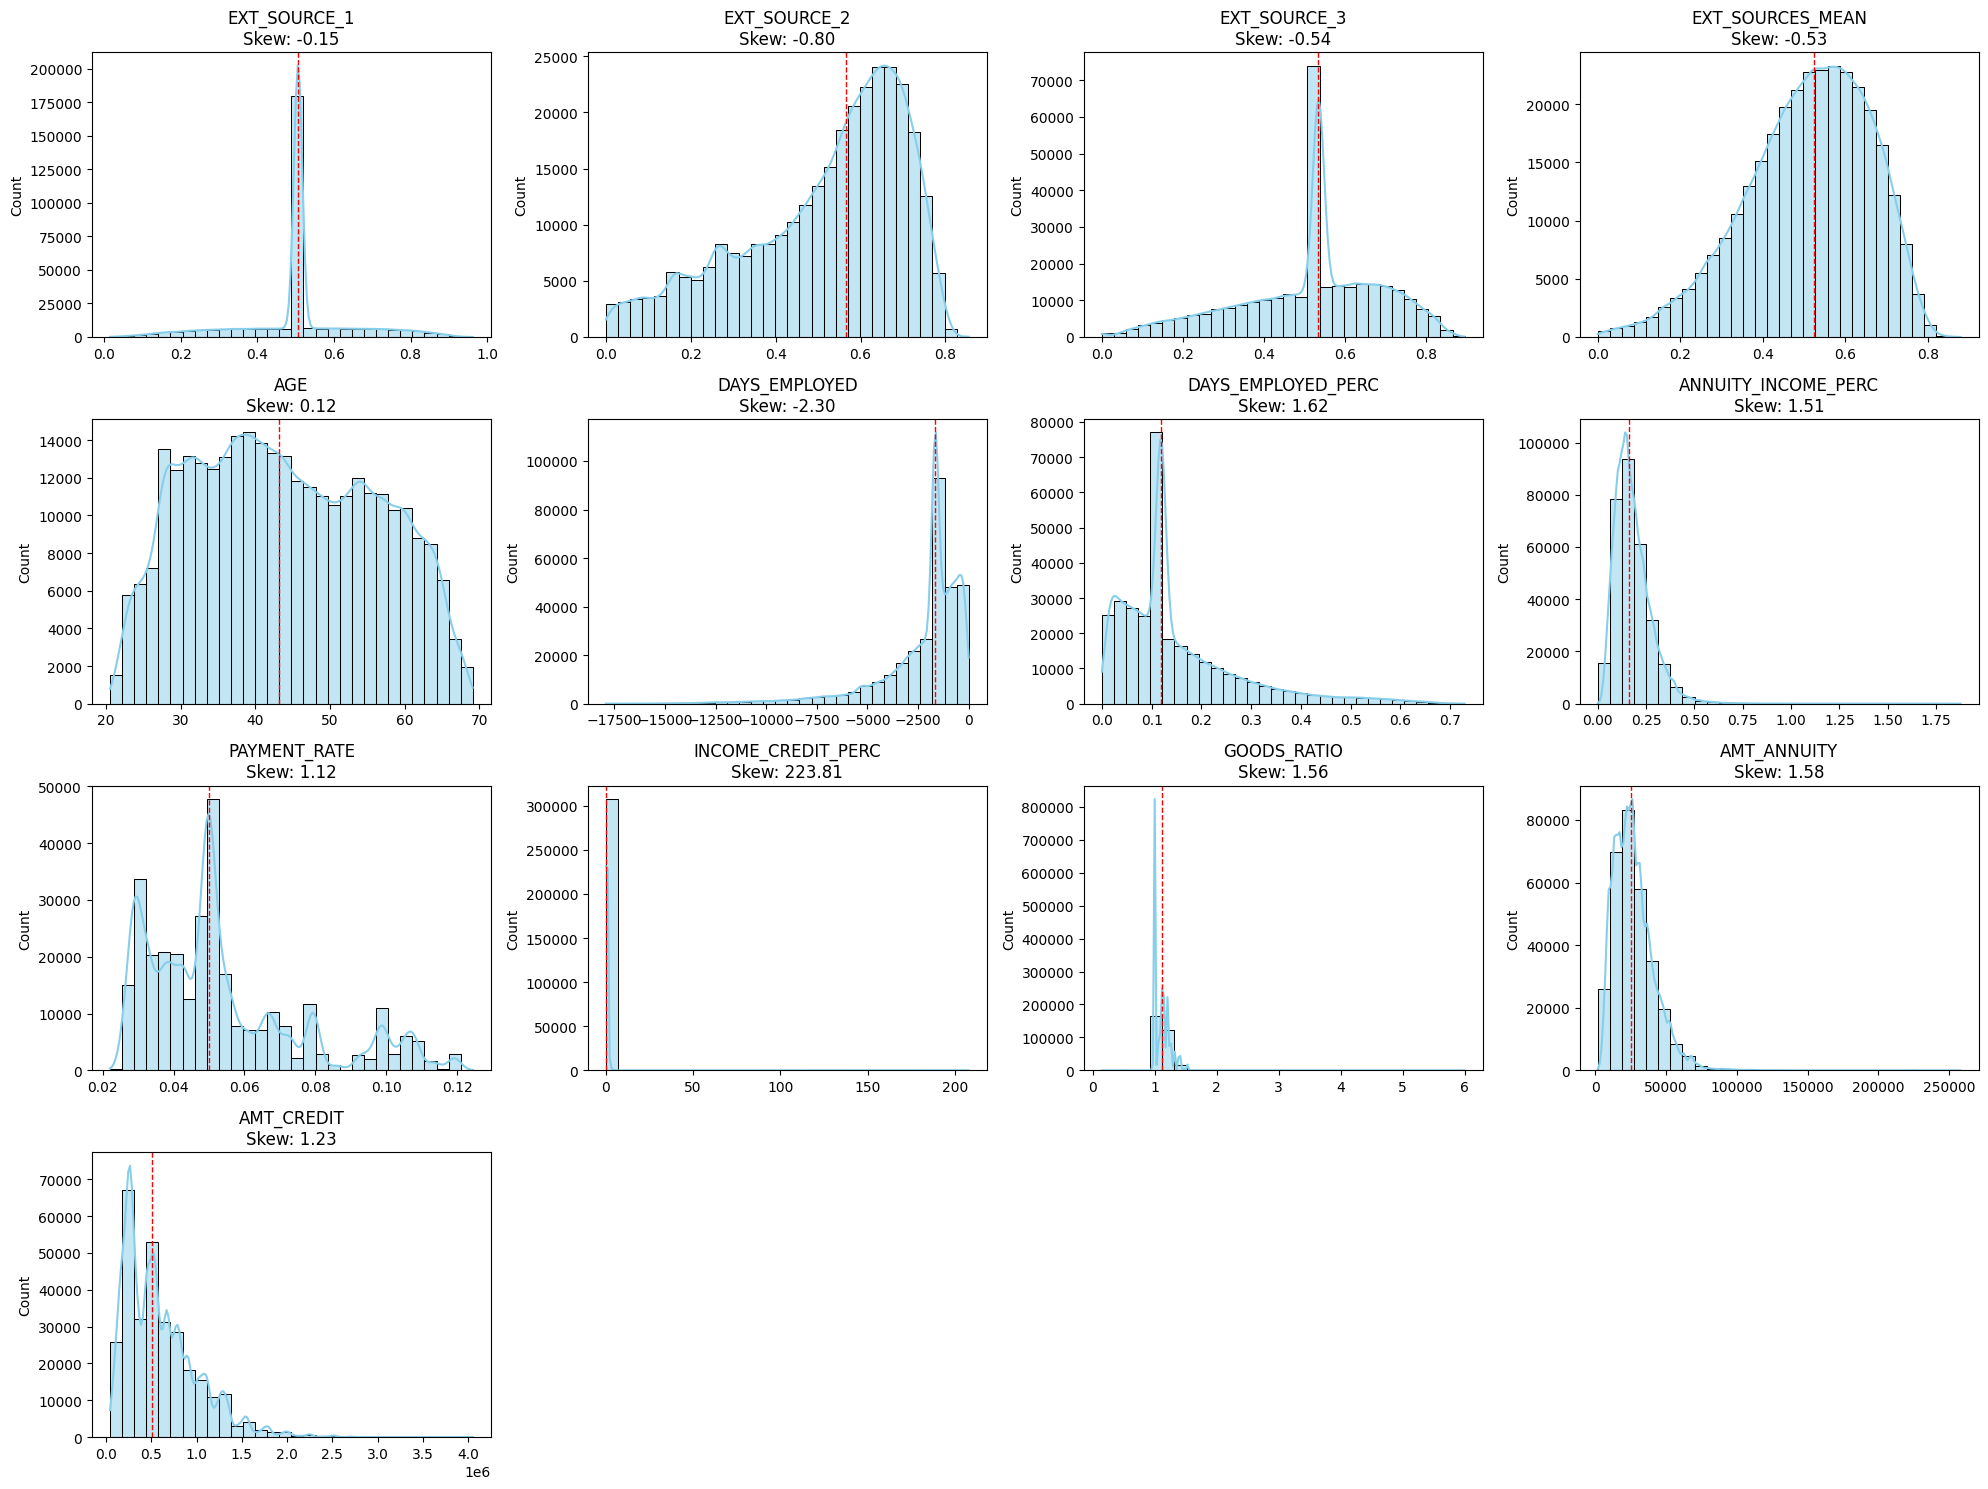

In [ ]:
# 1. Pilih kolom numerik inti (hindari kolom dummy hasil One-Hot Encoding)
numeric_cols = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCES_MEAN',
    'AGE', 'DAYS_EMPLOYED', 'DAYS_EMPLOYED_PERC',
    'ANNUITY_INCOME_PERC', 'PAYMENT_RATE', 'INCOME_CREDIT_PERC', 'GOODS_RATIO',
    'AMT_ANNUITY', 'AMT_CREDIT'
]

# 2. Hitung Nilai Skewness
skewness_values = df_ready[numeric_cols].skew().sort_values(ascending=False)
print("--- Nilai Skewness (Urut dari Tertinggi) ---")
print(skewness_values)

# 3. Visualisasi Histogram + KDE
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df_ready[col], kde=True, bins=30, color='skyblue')
    # Tambahkan garis median untuk melihat pergeseran
    plt.axvline(df_ready[col].median(), color='red', linestyle='dashed', linewidth=1)
    plt.title(f'{col}\nSkew: {df_ready[col].skew():.2f}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
#Log Transformation
# Daftar fitur yang benar-benar Right-Skewed (> 1)
# INCOME_CREDIT_PERC tetap masuk karena rasionya positif
cols_to_log = [
    'INCOME_CREDIT_PERC', 'AMT_ANNUITY', 'GOODS_RATIO',
    'ANNUITY_INCOME_PERC', 'AMT_CREDIT', 'PAYMENT_RATE',
    'DAYS_EMPLOYED_PERC'
]

for col in cols_to_log:
    # Menggunakan log1p agar aman dari nilai 0
    df_ready[f'{col}_LOG'] = np.log1p(df_ready[col])

# Untuk DAYS_EMPLOYED, kita buat versi absolutnya saja agar lebih intuitif
df_ready['DAYS_EMPLOYED_ABS'] = df_ready['DAYS_EMPLOYED'].abs()

# Hapus kolom asli yang sudah di-log agar tidak redundan (opsional)
df_ready.drop(columns=cols_to_log, inplace=True)

print("✅ Preprocessing & Log Transformation Final Selesai!")
print(f"Jumlah kolom saat ini: {df_ready.shape[1]}")

✅ Preprocessing & Log Transformation Final Selesai!
Jumlah kolom saat ini: 28


In [ ]:
# Drop days_employed
df_ready.drop(columns=['DAYS_EMPLOYED'], inplace=True)

In [ ]:
df_ready.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 27 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   TARGET                                             307511 non-null  int8   
 1   EXT_SOURCE_1                                       307511 non-null  float32
 2   EXT_SOURCE_2                                       307511 non-null  float32
 3   EXT_SOURCE_3                                       307511 non-null  float32
 4   EXT_SOURCES_MEAN                                   307511 non-null  float32
 5   EXT_SOURCES_NAN_COUNT                              307511 non-null  int64  
 6   AGE                                                307511 non-null  float64
 7   DAYS_EMPLOYED_ANOM                                 307511 non-null  int64  
 8   REGION_RATING_CLIENT_W_CITY                        307511 non-null  int8  

## Modelling

### Split data train/test

In [ ]:
# 1. Pisahkan Fitur (X) dan Target (y)
X = df_ready.drop(columns=['TARGET'])
y = df_ready['TARGET']

# 2. Lakukan Split
# test_size=0.2 artinya 20% data untuk testing
# random_state=42 agar hasil split konsisten jika di-run ulang
# stratify=y sangat penting untuk menjaga proporsi kelas TARGET
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- Hasil Split Data ---")
print(f"Jumlah Data Training (X_train): {X_train.shape[0]} baris")
print(f"Jumlah Data Testing (X_test):  {X_test.shape[0]} baris")
print(f"Proporsi Target di Train: \n{y_train.value_counts(normalize=True)}")
print(f"Proporsi Target di Test:  \n{y_test.value_counts(normalize=True)}")

--- Hasil Split Data ---
Jumlah Data Training (X_train): 246008 baris
Jumlah Data Testing (X_test):  61503 baris
Proporsi Target di Train: 
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
Proporsi Target di Test:  
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [ ]:
X_train.info(5)

<class 'pandas.core.frame.DataFrame'>
Index: 246008 entries, 181648 to 285162
Data columns (total 26 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   EXT_SOURCE_1                                       246008 non-null  float32
 1   EXT_SOURCE_2                                       246008 non-null  float32
 2   EXT_SOURCE_3                                       246008 non-null  float32
 3   EXT_SOURCES_MEAN                                   246008 non-null  float32
 4   EXT_SOURCES_NAN_COUNT                              246008 non-null  int64  
 5   AGE                                                246008 non-null  float64
 6   DAYS_EMPLOYED_ANOM                                 246008 non-null  int64  
 7   REGION_RATING_CLIENT_W_CITY                        246008 non-null  int8   
 8   NAME_EDUCATION_TYPE_Academic degree                246008 non-null  int64 

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61503 entries, 256571 to 268861
Data columns (total 26 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   EXT_SOURCE_1                                       61503 non-null  float32
 1   EXT_SOURCE_2                                       61503 non-null  float32
 2   EXT_SOURCE_3                                       61503 non-null  float32
 3   EXT_SOURCES_MEAN                                   61503 non-null  float32
 4   EXT_SOURCES_NAN_COUNT                              61503 non-null  int64  
 5   AGE                                                61503 non-null  float64
 6   DAYS_EMPLOYED_ANOM                                 61503 non-null  int64  
 7   REGION_RATING_CLIENT_W_CITY                        61503 non-null  int8   
 8   NAME_EDUCATION_TYPE_Academic degree                61503 non-null  int64  
 9   NAME_

### Scaling

In [ ]:
# 1. Definisikan list kolom numerik sesuai nama baru (setelah LOG transformation)
num_cols = [
    'INCOME_CREDIT_PERC_LOG', 'DAYS_EMPLOYED_PERC_LOG', 'AMT_ANNUITY_LOG',
    'GOODS_RATIO_LOG', 'ANNUITY_INCOME_PERC_LOG', 'AMT_CREDIT_LOG',
    'PAYMENT_RATE_LOG', 'AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
    'EXT_SOURCE_3', 'EXT_SOURCES_MEAN', 'DAYS_EMPLOYED_ABS'
]

# 2. Inisialisasi StandardScaler
scaler = StandardScaler()

# 3. FIT hanya pada data TRAINING
# Ini penting untuk mencegah 'data leakage' dari testing ke training
scaler.fit(X_train[num_cols])

# 4. TRANSFORM pada TRAINING dan TESTING
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Cek hasil
print("✅ Scaling Selesai!")
print(X_train[num_cols].head())

✅ Scaling Selesai!
        INCOME_CREDIT_PERC_LOG  DAYS_EMPLOYED_PERC_LOG  AMT_ANNUITY_LOG  \
181648                0.098093               -0.611859        -1.062115   
229245                0.659878               -1.299883        -1.075278   
122525               -0.742947               -0.534051         0.201767   
306311               -0.328048               -0.464091         0.705330   
300658                1.134224               -0.259843         0.286815   

        GOODS_RATIO_LOG  ANNUITY_INCOME_PERC_LOG  AMT_CREDIT_LOG  \
181648         1.160761                -0.346322       -1.028179   
229245         0.640045                -0.358289       -1.505288   
122525         1.566493                 0.192835        0.599266   
306311         0.745391                 0.850481       -0.001642   
300658         0.103453                -0.271914       -0.870432   

        PAYMENT_RATE_LOG       AGE  EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  \
181648          0.204802 -0.855291     -0

### Model Experiment

#### Decision Tree

In [ ]:
# 1. Inisialisasi Model dengan Algorithmic Weighting
# Kita tetap gunakan max_depth=10 sebagai batas awal agar tidak terlalu liar
dt_model = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)

# 2. Training Model
dt_model.fit(X_train, y_train)

# 3. Prediksi Probabilitas & Label (Training vs Testing)
# Untuk Training
train_probs = dt_model.predict_proba(X_train)[:, 1]
train_preds = dt_model.predict(X_train)

# Untuk Testing
test_probs = dt_model.predict_proba(X_test)[:, 1]
test_preds = dt_model.predict(X_test)

# 4. Evaluasi AUC-ROC
auc_train = roc_auc_score(y_train, train_probs)
auc_test = roc_auc_score(y_test, test_probs)

print(f"--- Perbandingan Performa ---")
print(f"AUC-ROC Training : {auc_train:.4f}")
print(f"AUC-ROC Testing  : {auc_test:.4f}")
print(f"Gap (Overfitting): {auc_train - auc_test:.4f}")

print("\n" + "="*30)
print("CLASSIFICATION REPORT (TESTING)")
print("="*30)
print(classification_report(y_test, test_preds))

--- Perbandingan Performa ---
AUC-ROC Training : 0.7836
AUC-ROC Testing  : 0.7063
Gap (Overfitting): 0.0774

CLASSIFICATION REPORT (TESTING)
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     56538
           1       0.15      0.66      0.24      4965

    accuracy                           0.66     61503
   macro avg       0.55      0.66      0.51     61503
weighted avg       0.89      0.66      0.74     61503



In [ ]:
# Decision Tree Tunning
# 1. Tentukan Parameter Grid
param_grid = {
    'max_depth': [5, 7, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# 2. Inisialisasi Model Baseline
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 3. Inisialisasi GridSearchCV
# Kita gunakan scoring='roc_auc' karena ini metrik utama kita
grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4. Fitting ke Data Training
grid_search.fit(X_train, y_train)

# 5. Ambil Model Terbaik
best_dt_model = grid_search.best_estimator_

print(f"✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
✅ Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
✅ Best Cross-Validation AUC: 0.7236


In [ ]:
def evaluate_model_performance(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Prediksi Probabilitas
    train_probs = model.predict_proba(X_train)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    # Hitung AUC-ROC
    auc_train = roc_auc_score(y_train, train_probs)
    auc_test = roc_auc_score(y_test, test_probs)

    # Prediksi Label untuk Classification Report
    test_preds = model.predict(X_test)

    print(f"--- Evaluasi Performa: {model_name} ---")
    print(f"AUC-ROC Training : {auc_train:.4f}")
    print(f"AUC-ROC Testing  : {auc_test:.4f}")
    print(f"Gap (Overfitting): {auc_train - auc_test:.4f}")
    print("\n" + "="*40)
    print(f"CLASSIFICATION REPORT (TESTING) - {model_name}")
    print("="*40)
    print(classification_report(y_test, test_preds))

In [ ]:
# Jalankan evaluasi untuk model terbaik
evaluate_model_performance(best_dt_model, X_train, y_train, X_test, y_test, "Tuned Decision Tree")

--- Evaluasi Performa: Tuned Decision Tree ---
AUC-ROC Training : 0.7425
AUC-ROC Testing  : 0.7301
Gap (Overfitting): 0.0124

CLASSIFICATION REPORT (TESTING) - Tuned Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56538
           1       0.15      0.67      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.67      0.52     61503
weighted avg       0.89      0.67      0.75     61503



#### Random Forest

In [ ]:
# 1. Inisialisasi Model
# n_jobs=-1 agar proses training menggunakan semua core CPU kamu
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, # Kita kunci kedalamannya sama dengan DT awal untuk perbandingan adil
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Training Model
rf_baseline.fit(X_train, y_train)

# 3. Evaluasi Menggunakan Fungsi yang Kita Buat Tadi
evaluate_model_performance(rf_baseline, X_train, y_train, X_test, y_test, "Random Forest Baseline")

--- Evaluasi Performa: Random Forest Baseline ---
AUC-ROC Training : 0.7990
AUC-ROC Testing  : 0.7462
Gap (Overfitting): 0.0528

CLASSIFICATION REPORT (TESTING) - Random Forest Baseline
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.17      0.61      0.27      4965

    accuracy                           0.73     61503
   macro avg       0.56      0.68      0.55     61503
weighted avg       0.89      0.73      0.79     61503



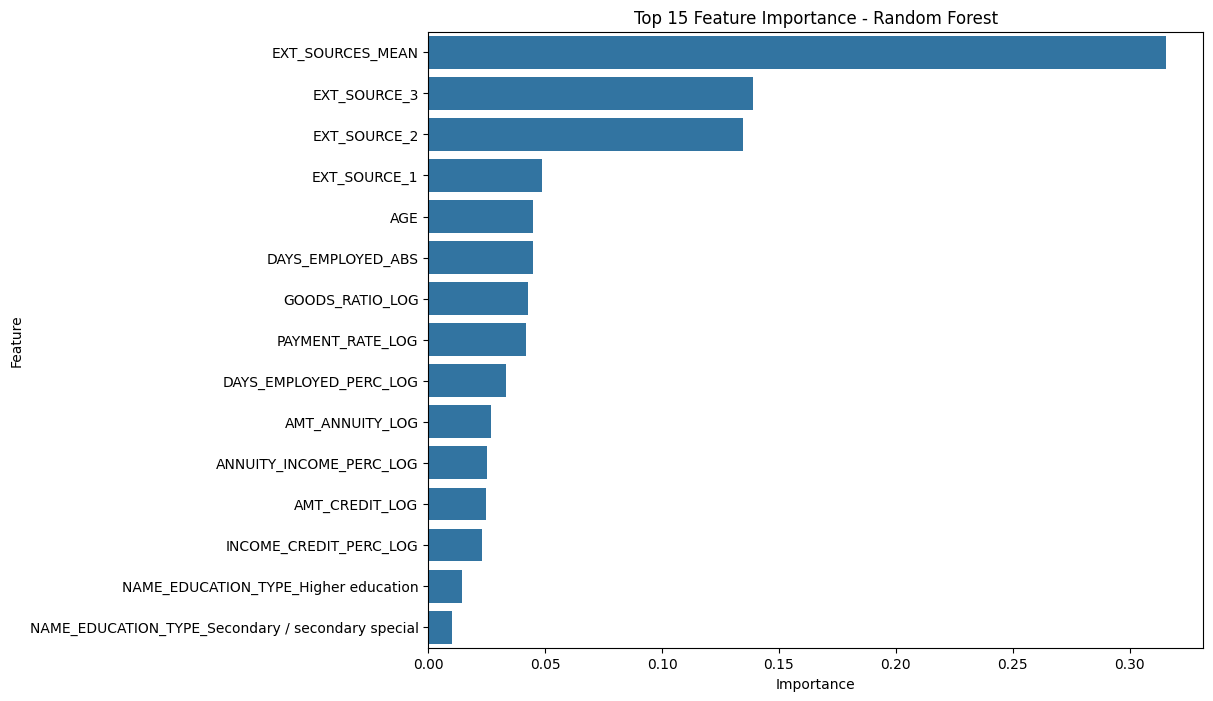

In [ ]:
# Ambil tingkat kepentingan fitur
importances = rf_baseline.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Feature Importance - Random Forest')
plt.show()

In [ ]:
# Tuning random forest
# 1. Tentukan Parameter Grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, 12],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] # Menentukan berapa fitur yang dicek di tiap split
}

# 2. Inisialisasi Model Dasar
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# 3. Jalankan RandomizedSearchCV
# n_iter=20 berarti kita hanya mencoba 20 kombinasi acak (lebih cepat dari GridSearch)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=3, # Menggunakan 3-fold agar lebih cepat
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_rf.fit(X_train, y_train)

# 4. Ambil Model Terbaik
best_rf_model = random_search_rf.best_estimator_

print(f"\n✅ Parameter Terbaik: {random_search_rf.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

#### XGBoost

In [ ]:
# 1. Hitung bobot untuk imbalance (92% : 8%)
# Rumus: total_negative / total_positive
ratio = 56538 / 4965 # Sekitar 11.38

# 2. Inisialisasi Model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # Rahasia menangani nasabah macet
    subsample=0.8,         # Mengambil 80% data per pohon untuk cegah overfit
    colsample_bytree=0.8,  # Mengambil 80% fitur per pohon
    tree_method='hist',    # WAJIB: Agar sangat cepat pada data besar
    random_state=42,
    n_jobs=-1
)

# 3. Training (Mari kita lihat apakah ini lebih cepat dari 2 jam!)
xgb_model.fit(X_train, y_train)

# 4. Evaluasi (Gunakan fungsi perbandingan kita)
evaluate_model_performance(xgb_model, X_train, y_train, X_test, y_test, "XGBoost Baseline")

--- Evaluasi Performa: XGBoost Baseline ---
AUC-ROC Training : 0.7989
AUC-ROC Testing  : 0.7605
Gap (Overfitting): 0.0384

CLASSIFICATION REPORT (TESTING) - XGBoost Baseline
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503



In [ ]:
# Tuning XGBoost
# 1. Definisikan Ruang Parameter
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'gamma': [0, 0.1, 0.2, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [ratio] # Kita kunci di rasio imbalance awal
}

# 2. Inisialisasi Model Dasar
xgb_base = XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1)

# 3. Jalankan RandomizedSearchCV
# n_iter=15 sudah cukup untuk mendapatkan peningkatan tanpa menunggu lama
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

# 4. Ambil Model Terbaik
best_xgb_model = random_search_xgb.best_estimator_

print(f"\n✅ Parameter Terbaik XGBoost: {random_search_xgb.best_params_}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Parameter Terbaik XGBoost: {'subsample': 1.0, 'scale_pos_weight': 11.387311178247733, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [ ]:
evaluate_model_performance(best_xgb_model, X_train, y_train, X_test, y_test, "Tuned XGBoost")

--- Evaluasi Performa: Tuned XGBoost ---
AUC-ROC Training : 0.7993
AUC-ROC Testing  : 0.7616
Gap (Overfitting): 0.0377

CLASSIFICATION REPORT (TESTING) - Tuned XGBoost
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503



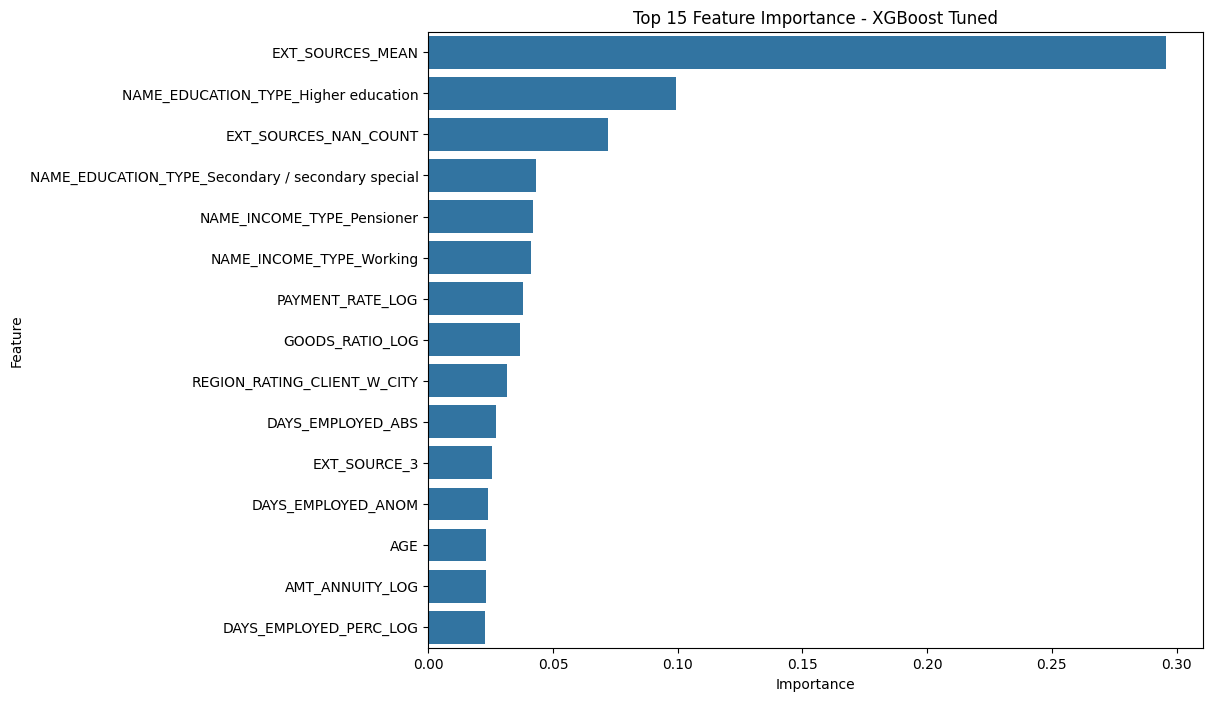

In [ ]:
# Ambil tingkat kepentingan fitur
importances = best_xgb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Feature Importance - XGBoost Tuned')
plt.show()

#### LightGBM

In [ ]:
# 1. Inisialisasi Model
# is_unbalance=True secara otomatis menghitung bobot seperti scale_pos_weight
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,         # Parameter utama LightGBM (Leaf-wise)
    is_unbalance=True,     # Menangani imbalance secara otomatis
    random_state=42,
    n_jobs=-1,
    importance_type='gain' # Agar feature importance lebih akurat (mirip XGBoost)
)

# 2. Training
lgbm_model.fit(X_train, y_train)

# 3. Evaluasi (Tetap menggunakan protokol perbandingan Train vs Test)
evaluate_model_performance(lgbm_model, X_train, y_train, X_test, y_test, "LightGBM Baseline")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3345
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
--- Evaluasi Performa: LightGBM Baseline ---
AUC-ROC Training : 0.7910
AUC-ROC Testing  : 0.7614
Gap (Overfitting): 0.0296

CLASSIFICATION REPORT (TESTING) - LightGBM Baseline
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.68      0.27      4965

    accuracy        

In [ ]:
#Tuning LightGBM
# 1. Definisikan Ruang Parameter
param_grid_lgbm = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40, 50],
    'max_depth': [-1, 5, 10, 15], # -1 berarti tidak ada batasan kedalaman
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5],
    'is_unbalance': [True]
}

# 2. Inisialisasi Model Dasar
lgbm_base = LGBMClassifier(random_state=42, n_jobs=-1, importance_type='gain')

# 3. Jalankan RandomizedSearchCV
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid_lgbm,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

# 4. Ambil Model Terbaik
best_lgbm_model = random_search_lgbm.best_estimator_

print(f"\n✅ Parameter Terbaik LightGBM: {random_search_lgbm.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3343
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

✅ Parameter Terbaik LightGBM: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 20, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.05, 'is_unbalance': True, 'colsample_bytree': 0.7}


In [ ]:
evaluate_model_performance(best_lgbm_model, X_train, y_train, X_test, y_test, "Tuned LightGBM")

--- Evaluasi Performa: Tuned LightGBM ---
AUC-ROC Training : 0.7784
AUC-ROC Testing  : 0.7615
Gap (Overfitting): 0.0168

CLASSIFICATION REPORT (TESTING) - Tuned LightGBM
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.69      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503



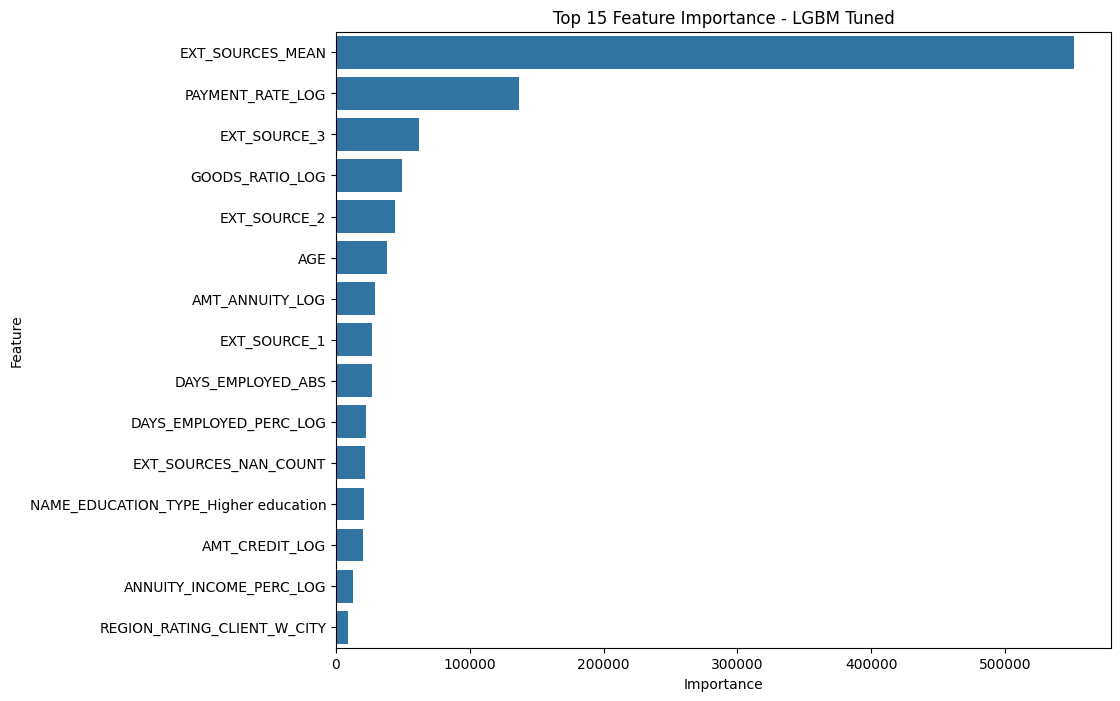

In [ ]:
# Ambil tingkat kepentingan fitur
importances = best_lgbm_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Feature Importance - LGBM Tuned')
plt.show()

#### Shap Value (Explaineble AI)

⏳ Menghitung SHAP Values (ini mungkin memakan waktu 1-2 menit)...


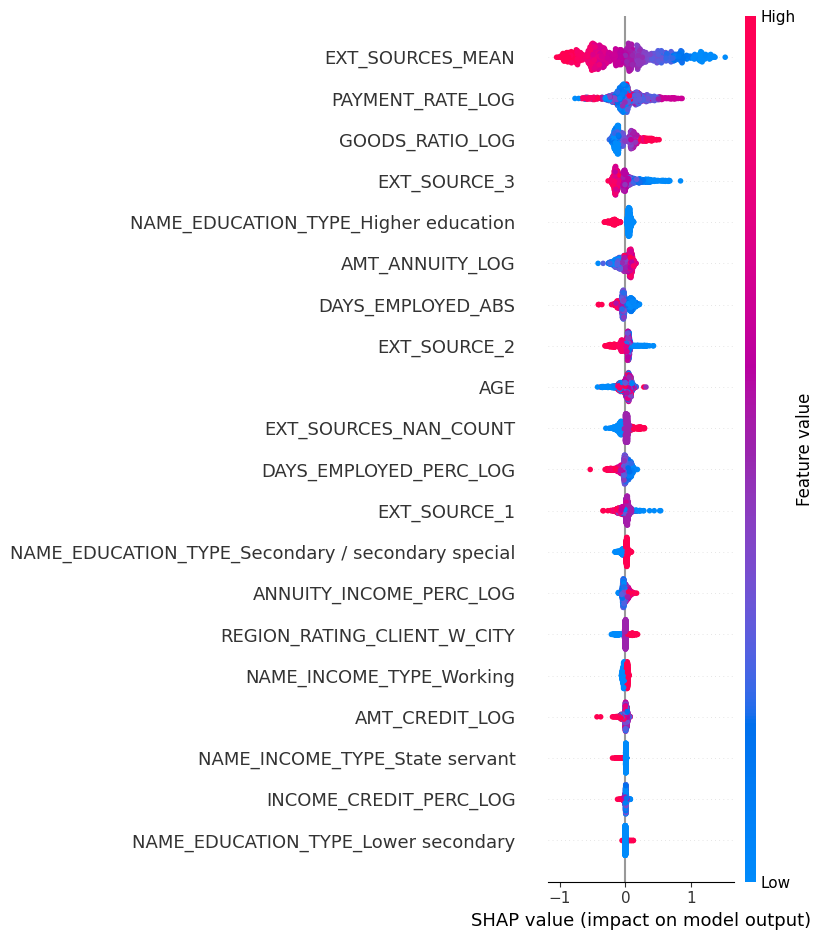

In [ ]:
# 1. Ambil Sampel dari Data Train (500 - 1000 baris cukup representatif)
# Menggunakan random_state agar hasilnya konsisten
X_shap_train = X_train.sample(1000, random_state=42)

# 2. Inisialisasi SHAP TreeExplainer
# TreeExplainer dioptimalkan khusus untuk model berbasis pohon (LGBM/XGB)
print("⏳ Menghitung SHAP Values (ini mungkin memakan waktu 1-2 menit)...")
explainer = shap.TreeExplainer(best_lgbm_model)
shap_values = explainer.shap_values(X_shap_train)

# 3. Visualisasi: SHAP Summary Plot
# Jika shap_values adalah list of arrays (untuk multi-class), shap_values[1] akan jadi matrix.
# Namun, jika shap_values sudah 2D (untuk binary class dengan satu output), maka langsung gunakan shap_values.
# Berdasarkan error dan kernel state, shap_values tampaknya langsung 2D.
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_train, feature_names=X_shap_train.columns)

#### Save The Best Model (LightGBM)

In [ ]:
# 1. Simpan Model Terbaik (Tuned LightGBM)
model_filename = 'home_credit_lgbm_tuned.joblib'
joblib.dump(best_lgbm_model, model_filename)

# 2. (Opsional tapi Disarankan) Simpan Scaler atau List Fitur
# Jika kamu menggunakan Scaler saat preprocessing:
joblib.dump(scaler, 'scaler_home_credit.joblib')

print(f"✅ Model berhasil disimpan dengan nama: {model_filename}")

✅ Model berhasil disimpan dengan nama: home_credit_lgbm_tuned.joblib


## Predict Application Test

In [ ]:
def final_prediction_pipeline(test_csv_path, model_path, scaler_path, output_filename='submission.csv'):
    """
    Fungsi otomatis untuk membaca data test, melakukan transformasi,
    dan menghasilkan file submission sesuai standar Kaggle.
    """
    print("⏳ Memulai proses prediksi final...")

    # 1. Load Data
    test_df = pd.read_csv(test_csv_path)
    sk_id = test_df['SK_ID_CURR'] # Simpan untuk kolom submission

    # 2. Feature Engineering (Replikasi Tahap Training)
    # A. Membuat EXT_SOURCES_MEAN
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    test_df['EXT_SOURCES_MEAN'] = test_df[ext_cols].mean(axis=1)

    # B. Membuat payment_rate_Log
    # Pastikan fitur pendukung (AMT_ANNUITY & AMT_CREDIT) tidak ada yang nol untuk menghindari error
    test_df['PAYMENT_RATE'] = test_df['AMT_ANNUITY'] / test_df['AMT_CREDIT'].replace(0, np.nan)
    test_df['payment_rate_Log'] = np.log1p(test_df['PAYMENT_RATE'])

    # 3. Load Model & Scaler
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    # 4. Sinkronisasi Fitur
    # Sangat penting: Ambil hanya kolom yang digunakan model saat training dalam urutan yang benar
    # LightGBM menyimpan nama fitur di atribut .feature_name_
    try:
        features_used = model.feature_name_
    except AttributeError:
        # Jika model tidak menyimpan nama fitur, pastikan urutan kolom sesuai manual
        # Di sini kita asumsikan model memiliki atribut tersebut
        features_used = scaler.feature_names_in_

    X_test = test_df[features_used]

    # 5. Handling Missing Values untuk Scaling
    # Scaler biasanya tidak bisa menerima NaN. Kita isi dengan median atau 0
    # sesuai dengan yang dilakukan pada tahap training sebelumnya.
    X_test_filled = X_test.fillna(X_test.median())

    # 6. Transformasi (Scaling)
    X_test_scaled = scaler.transform(X_test_filled)

    # 7. Prediksi Probabilitas (Kelas 1 - Macet)
    print("🔮 Melakukan prediksi probabilitas...")
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # 8. Generate Submission File
    submission = pd.DataFrame({
        'SK_ID_CURR': sk_id,
        'TARGET': y_proba
    })

    submission.to_csv(output_filename, index=False)
    print(f"✅ Selesai! File submission disimpan sebagai: {output_filename}")
    return submission

In [ ]:
# 1. Tentukan Nama File
TEST_FILE = '/content/datasets/application_test.csv'
MODEL_FILE = 'home_credit_lgbm_tuned.joblib'
SCALER_FILE = 'scaler_home_credit.joblib'
OUTPUT_FILE = 'submission_home_credit_final.csv'

def run_final_prediction(test_path, model_path, scaler_path):
    print(f"📖 Membaca data {test_path}...")
    df = pd.read_csv(test_path)
    sk_id_curr = df['SK_ID_CURR']

    # --- 1. FEATURE ENGINEERING DASAR ---
    df['EXT_SOURCES_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCES_NAN_COUNT'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isnull().sum(axis=1)
    df['AGE'] = df['DAYS_BIRTH'] / -365
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED_ABS'] = df['DAYS_EMPLOYED'].abs()

    # Ratios (Numerical)
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['GOODS_RATIO'] = df['AMT_GOODS_PRICE'] / df['AMT_CREDIT']
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

    # --- 2. LOG TRANSFORMATION ---
    cols_to_log = {
        'INCOME_CREDIT_PERC': 'INCOME_CREDIT_PERC_LOG',
        'AMT_ANNUITY': 'AMT_ANNUITY_LOG',
        'GOODS_RATIO': 'GOODS_RATIO_LOG',
        'ANNUITY_INCOME_PERC': 'ANNUITY_INCOME_PERC_LOG',
        'AMT_CREDIT': 'AMT_CREDIT_LOG',
        'PAYMENT_RATE': 'PAYMENT_RATE_LOG',
        'DAYS_EMPLOYED_PERC': 'DAYS_EMPLOYED_PERC_LOG'
    }
    for original, log_col in cols_to_log.items():
        df[log_col] = np.log1p(df[original])

    # --- 3. KATEGORIKAL (GROUPING & DUMMIES) ---
    valid_incomes = ['Working', 'Commercial associate', 'Pensioner', 'State servant']
    df['NAME_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].apply(lambda x: x if x in valid_incomes else 'Other')

    # One-Hot Encoding
    categorical_cols = ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']
    df = pd.get_dummies(df, columns=categorical_cols, dtype=int)

    # --- 4. PENYUSUNAN 26 KOLOM (URUTAN WAJIB SAMA) ---
    # List ini disesuaikan persis dengan info() yang kamu berikan
    final_26_columns = [
        'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCES_MEAN', 'EXT_SOURCES_NAN_COUNT',
        'AGE', 'DAYS_EMPLOYED_ANOM', 'REGION_RATING_CLIENT_W_CITY',
        'NAME_EDUCATION_TYPE_Academic degree', 'NAME_EDUCATION_TYPE_Higher education',
        'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary',
        'NAME_EDUCATION_TYPE_Secondary / secondary special',
        'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Other',
        'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working',
        'INCOME_CREDIT_PERC_LOG', 'AMT_ANNUITY_LOG', 'GOODS_RATIO_LOG',
        'ANNUITY_INCOME_PERC_LOG', 'AMT_CREDIT_LOG', 'PAYMENT_RATE_LOG',
        'DAYS_EMPLOYED_PERC_LOG', 'DAYS_EMPLOYED_ABS'
    ]

    # Reindex untuk memastikan 26 kolom ada & urutannya benar
    X_test = df.reindex(columns=final_26_columns, fill_value=0)

    # Impute sisa NaN dengan median (penting sebelum scaling)
    X_test = X_test.fillna(X_test.median())

    # --- 5. SCALING HANYA PADA 13 KOLOM NUMERIK ---
    num_cols_to_scale = [
        'INCOME_CREDIT_PERC_LOG', 'DAYS_EMPLOYED_PERC_LOG', 'AMT_ANNUITY_LOG',
        'GOODS_RATIO_LOG', 'ANNUITY_INCOME_PERC_LOG', 'AMT_CREDIT_LOG',
        'PAYMENT_RATE_LOG', 'AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
        'EXT_SOURCE_3', 'EXT_SOURCES_MEAN', 'DAYS_EMPLOYED_ABS'
    ]

    print("📂 Loading model dan scaler...")
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    # Terapkan scaling pada bagian kolom numerik
    X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

    # --- 6. PREDIKSI ---
    print("🔮 Melakukan Prediksi Final...")
    y_proba = model.predict_proba(X_test)[:, 1]

    # Simpan ke CSV
    submission = pd.DataFrame({'SK_ID_CURR': sk_id_curr, 'TARGET': y_proba})
    submission.to_csv('submission_final_26cols.csv', index=False)
    print("✅ SELESAI! File 'submission_final_26cols.csv' telah dibuat.")
    return submission.head()

# Eksekusi!
final_output_preview = run_final_prediction(TEST_FILE, MODEL_FILE, SCALER_FILE)
print("\nPreview Hasil Prediksi:")
print(final_output_preview)

📖 Membaca data /content/datasets/application_test.csv...
📂 Loading model dan scaler...
🔮 Melakukan Prediksi Final...
✅ SELESAI! File 'submission_final_26cols.csv' telah dibuat.

Preview Hasil Prediksi:
   SK_ID_CURR    TARGET
0      100001  0.242146
1      100005  0.367771
2      100013  0.163750
3      100028  0.324534
4      100038  0.669314
